# 04 — Training

Train the transformer to predict the next token in Gambler's Ruin sequences
via cross-entropy loss.  Save the best checkpoint to disk.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset, random_split
from tqdm.auto import tqdm

/Users/ashrafahmed/code/slt-deep/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'


# Resolve project root and add project-local packages/ to sys.path.
cwd = Path.cwd().resolve()
project_root = next(
    (
        p
        for p in (cwd, *cwd.parents)
        if (p / "packages" / "pytorch_models" / "markov_transformer.py").exists()
    ),
    None,
)
if project_root is None:
    alt_root = cwd / "projects" / "markov-chain-learning"
    if (alt_root / "packages" / "pytorch_models" / "markov_transformer.py").exists():
        project_root = alt_root

if project_root is None:
    raise RuntimeError(
        "Could not locate markov-chain-learning project root from current working directory"
    )

packages_dir = project_root / "packages"
if str(packages_dir) not in sys.path:
    sys.path.insert(0, str(packages_dir))

from pytorch_models import MarkovTransformer

## Configuration

In [3]:
# -- Papermill parameters -----------------------------------------------------
DATA_DIR = str(project_root / "experiments" / "single-chain" / "data")
DATA_DIR = Path(DATA_DIR)
print("Data dir:", DATA_DIR.resolve())

Data dir: /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data


In [4]:
# -- Post-papermill coercions -------------------------------------------------
# Training
BATCH_SIZE = 256  # 256
EPOCHS = 100
LR = 3e-3
VAL_SPLIT = 0.1
SEED = 42
# Save only every N epochs to reduce checkpoint count during fast iteration.
CHECKPOINT_EVERY = 10

EPOCHS = int(EPOCHS)
BATCH_SIZE = int(BATCH_SIZE)
SEED = int(SEED)
CHECKPOINT_EVERY = int(CHECKPOINT_EVERY)

torch.manual_seed(SEED)

## Load data

In [5]:
class MarkovSequenceDataset(Dataset):
    def __init__(self, sequences: torch.Tensor):
        self.data = sequences

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        return self.data[idx]


data = torch.load(DATA_DIR / "sequences.pt", weights_only=False)
sequences = data["sequences"]
Ts = data["Ts"]
pis = data["pis"]

data_cfg = data.get("config")
if not isinstance(data_cfg, dict):
    raise KeyError("Dataset is missing required metadata: data['config']")

required_keys = ("n_states", "L")
missing_keys = [k for k in required_keys if k not in data_cfg]
if missing_keys:
    raise KeyError(
        f"Dataset config missing required keys: {missing_keys}. "
        "Regenerate the dataset with 02_dataset.ipynb."
    )

try:
    VOCAB_SIZE = int(data_cfg["n_states"])
    MAX_LEN = int(data_cfg["L"])
except (TypeError, ValueError) as exc:
    raise ValueError(
        "Dataset config keys 'n_states' and 'L' must be integer-like values."
    ) from exc

if VOCAB_SIZE <= 0 or MAX_LEN <= 0:
    raise ValueError(
        f"Dataset config has invalid dimensions: n_states={VOCAB_SIZE}, L={MAX_LEN}"
    )

if int(sequences.shape[1]) != MAX_LEN:
    raise ValueError(
        f"Dataset config mismatch: L={MAX_LEN} but sequences.shape[1]={sequences.shape[1]}"
    )

PAD_ID = int(data_cfg.get("pad_id", -1))
DGP_REGIME = data_cfg.get("dgp_regime", "unknown")

print(f"DGP regime  : {DGP_REGIME}")
print(f"Loaded {len(sequences)} sequences, shape {tuple(sequences.shape)}")
print(
    f"PAD_ID={PAD_ID}, Ts shape: {tuple(Ts.shape)}, VOCAB_SIZE={VOCAB_SIZE}, MAX_LEN={MAX_LEN}"
)

full_ds = MarkovSequenceDataset(sequences)
n_val = int(len(full_ds) * VAL_SPLIT)
n_train = len(full_ds) - n_val
train_ds, val_ds = random_split(
    full_ds,
    [n_train, n_val],
    generator=torch.Generator().manual_seed(SEED),
)
train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
print(f"Train: {n_train}   Val: {n_val}")

DGP regime  : single
Loaded 3000 sequences, shape (3000, 10)
PAD_ID=-1, Ts shape: (1, 5, 5), VOCAB_SIZE=5, MAX_LEN=10
Train: 2700   Val: 300


## Training loop

In [6]:
device = torch.device("cpu")
print("Device:", device)

D_MODEL = VOCAB_SIZE * 2
model = MarkovTransformer(
    vocab_size=VOCAB_SIZE,
    d_model=D_MODEL,
    max_len=MAX_LEN,
).to(device)

optimizer = torch.optim.Adam(model.parameters(), lr=LR)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_ID)
print(model)

Device: cpu


MarkovTransformer(
  (input_proj): Linear(in_features=5, out_features=10, bias=False)
  (rel_pos_bias): Embedding(10, 1)
  (layers): ModuleList(
    (0-1): 2 x Attention(
      (W_q): Linear(in_features=10, out_features=10, bias=False)
      (W_k): Linear(in_features=10, out_features=10, bias=False)
      (W_v): Linear(in_features=10, out_features=10, bias=False)
      (W_o): Linear(in_features=10, out_features=10, bias=False)
    )
  )
  (head): Linear(in_features=10, out_features=5, bias=False)
)


In [7]:
total = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {total:,}")
print(f"Trainable parameters: {trainable:,}")

# Per-module breakdown
for name, module in model.named_children():
    n = sum(p.numel() for p in module.parameters())
    print(f"  {name:<20} {n:>6,} params")

Total parameters    : 910
Trainable parameters: 910
  input_proj               50 params
  rel_pos_bias             10 params
  layers                  800 params
  head                     50 params


In [8]:
def run_epoch(loader, training: bool):
    model.train(training)
    total_loss, n_tokens = 0.0, 0
    with torch.set_grad_enabled(training):
        for batch in loader:
            batch = batch.to(device)
            x_in = batch[:, :-1]
            x_tgt = batch[:, 1:]
            # Replace PAD_ID with 0 for one_hot encoding (loss ignores these positions)
            x_in = x_in.clone()
            x_in[x_in == PAD_ID] = 0
            logits = model(x_in)
            _, _, vocab_dim = logits.shape
            loss = criterion(logits.reshape(-1, vocab_dim), x_tgt.reshape(-1))

            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

            valid_tokens = (x_tgt != PAD_ID).sum().item()
            total_loss += loss.item() * valid_tokens
            n_tokens += valid_tokens

    return total_loss / max(n_tokens, 1)


checkpoints_dir = DATA_DIR / "checkpoints"
checkpoints_dir.mkdir(exist_ok=True)

train_losses, val_losses, grad_norms = [], [], []
best_val_loss = float("inf")
ckpt_name = "checkpoint_single_chain.pt"

for epoch in tqdm(range(1, EPOCHS + 1), desc="Training"):
    tr_loss = run_epoch(train_loader, training=True)
    val_loss = run_epoch(val_loader, training=False)
    train_losses.append(tr_loss)
    val_losses.append(val_loss)

    gnorm = (
        sum(p.grad.norm().item() ** 2 for p in model.parameters() if p.grad is not None)
        ** 0.5
    )
    grad_norms.append(gnorm)

    epoch_ckpt = {
        "model_state": model.state_dict(),
        "config": dict(vocab_size=VOCAB_SIZE, d_model=D_MODEL, max_len=MAX_LEN),
        "epoch": epoch,
        "train_loss": tr_loss,
        "val_loss": val_loss,
        "training": {
            "architecture": "pytorch_models.MarkovTransformer",
            "dgp_regime": DGP_REGIME,
        },
    }

    if epoch % CHECKPOINT_EVERY == 0 or epoch == EPOCHS:
        torch.save(epoch_ckpt, checkpoints_dir / f"checkpoint_epoch_{epoch:04d}.pt")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(
            {**epoch_ckpt, "best_val_loss": best_val_loss},
            DATA_DIR / ckpt_name,
        )

torch.save(
    {
        "epochs": list(range(1, EPOCHS + 1)),
        "train_losses": train_losses,
        "val_losses": val_losses,
        "grad_norms": grad_norms,
    },
    DATA_DIR / "training_history.pt",
)

print(f"\nBest val loss : {best_val_loss:.4f}  (checkpoint: {ckpt_name})")
print(f"Uniform entropy: {torch.log(torch.tensor(float(VOCAB_SIZE))):.4f}")
print(f"Per-epoch checkpoints saved to: {checkpoints_dir}")

Training: 100%|██████████| 100/100 [00:05<00:00, 18.47it/s]


Best val loss : 1.2806  (checkpoint: checkpoint_single_chain.pt)
Uniform entropy: 1.6094
Per-epoch checkpoints saved to: /Users/ashrafahmed/code/slt-deep/projects/markov-chain-learning/experiments/single-chain/data/checkpoints


## Loss curve

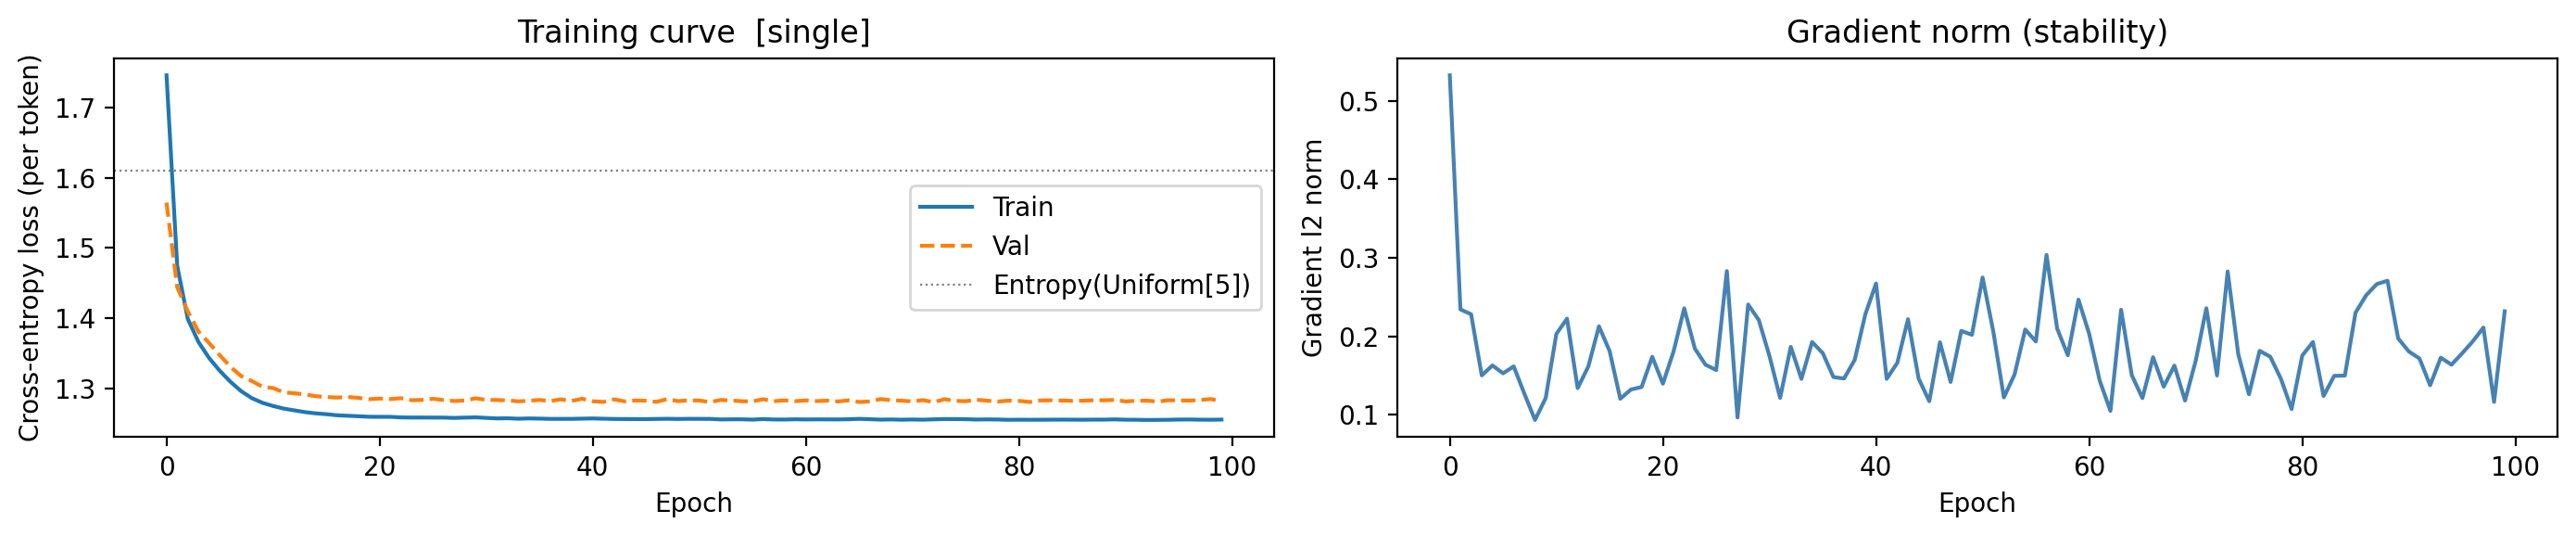

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 3))

axes[0].plot(train_losses, label="Train")
axes[0].plot(val_losses, label="Val", linestyle="--")
axes[0].axhline(
    torch.log(torch.tensor(float(VOCAB_SIZE))).item(),
    color="gray",
    linestyle=":",
    linewidth=0.8,
    label=f"Entropy(Uniform[{VOCAB_SIZE}])",
)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Cross-entropy loss (per token)")
axes[0].set_title(f"Training curve  [{DGP_REGIME}]")
axes[0].legend()

axes[1].plot(grad_norms, color="steelblue")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Gradient l2 norm")
axes[1].set_title("Gradient norm (stability)")

plt.tight_layout()
plt.show()

## Hessian at MLE


In [ ]:
import torch.nn.functional as F


def loss_fn(logits, targets):
    ce = F.cross_entropy(
        logits.reshape(-1, VOCAB_SIZE),
        targets.reshape(-1),
        reduction="none",
        ignore_index=PAD_ID,
    )
    ce = ce.view(logits.shape[:-1])
    mask = (targets != PAD_ID).float()
    return (ce * mask).sum() / mask.sum()


def compute_hessian_at_map(model, loss_fn, x_data, y_data):
    """Approximate Hessian of loss at current model parameters.
    Returns (eigvals, eigvecs, H) — eigendecomposition on CPU."""
    from torch_bdn.bn.bayesian_net import approx_hessian

    H = approx_hessian(model, loss_fn, x_data, y_data, chunk_size=10240).cpu()
    eigvals, eigvecs = torch.linalg.eigh(H)
    return eigvals, eigvecs, H


### Final-model Hessian


In [11]:
# Prepare data for BayesianNet
x_data = sequences[:, :-1].to(device)
y_data = sequences[:, 1:].to(device)
# Replace PAD_ID with 0 in x_data to avoid one_hot error
x_data = x_data.clone()
x_data[x_data == PAD_ID] = 0

print("\nComputing the Hessian at MLE...")
hessian_results = {}
try:
    eigvals, eigvecs, H = compute_hessian_at_map(model, loss_fn, x_data, y_data)

    hessian_results["eigvals"] = eigvals
    hessian_results["eigvecs"] = eigvecs
    hessian_results["hessian"] = H

    print(f"✓ (λ_min={eigvals[0]:.2e}, λ_max={eigvals[-1]:.2e})")
except Exception as e:
    print(f"✗ Error: {e}")


Computing the Hessian at MLE...
✓ (λ_min=-7.34e-02, λ_max=3.97e+00)


In [ ]:
# ── Save raw Hessian + MLE parameters ──
# Saved RAW — no clamping, no prior. Downstream notebooks pick their own regularization.
hessian_path = DATA_DIR / "hessian.pt"
mle_param = torch.cat([p.detach().flatten() for p in model.parameters()]).cpu()

torch.save(
    {
        "H_mle": H.cpu(),
        "mle_param": mle_param,
        "vocab_size": VOCAB_SIZE,
        "d": int(H.shape[0]),
        "dgp_regime": DGP_REGIME,
    },
    hessian_path,
)

n_neg = int((eigvals < 0).sum())
n_pos = int((eigvals > 0).sum())
print(f"Saved Hessian + MLE to {hessian_path}")
print(f"  H shape: {tuple(H.shape)}, d={H.shape[0]}")
print(f"  λ ∈ [{eigvals[0]:.4e}, {eigvals[-1]:.4e}]")
print(f"  positive: {n_pos}, negative: {n_neg} (numerical noise from chunked float32)")


## Hessian spectrum across checkpoints

Recompute Hessian at each saved checkpoint to see how the spectrum evolves over training.
Eigenvalues only (full Hessians per epoch would be too large to persist).


In [ ]:
# ── Per-checkpoint Hessian eigenspectra ──
import re
from torch_bdn.bn.bayesian_net import approx_hessian

ckpt_files = sorted(checkpoints_dir.glob("checkpoint_epoch_*.pt"))
print(f"Found {len(ckpt_files)} per-epoch checkpoints")

per_epoch_epochs = []
per_epoch_eigvals = []
per_epoch_train_loss = []
per_epoch_val_loss = []

ckpt_model = type(model)(vocab_size=VOCAB_SIZE, d_model=D_MODEL, max_len=MAX_LEN).to(device)

for ckpt_path in tqdm(ckpt_files, desc="Per-epoch Hessian"):
    m = re.search(r"checkpoint_epoch_(\d+)\.pt", ckpt_path.name)
    if not m:
        continue
    epoch = int(m.group(1))

    ckpt = torch.load(ckpt_path, weights_only=False, map_location=device)
    ckpt_model.load_state_dict(ckpt["model_state"])
    ckpt_model.eval()

    H_ck = approx_hessian(ckpt_model, loss_fn, x_data, y_data, chunk_size=10240).cpu()
    eigvals_ck = torch.linalg.eigvalsh(H_ck)

    per_epoch_epochs.append(epoch)
    per_epoch_eigvals.append(eigvals_ck)
    per_epoch_train_loss.append(ckpt.get("train_loss", float("nan")))
    per_epoch_val_loss.append(ckpt.get("val_loss", float("nan")))

if per_epoch_eigvals:
    eigvals_per_epoch = torch.stack(per_epoch_eigvals)
    torch.save(
        {
            "epochs": per_epoch_epochs,
            "eigvals_per_epoch": eigvals_per_epoch,
            "train_losses": per_epoch_train_loss,
            "val_losses": per_epoch_val_loss,
        },
        DATA_DIR / "hessians_per_epoch.pt",
    )
    print(f"\nSaved per-epoch eigenspectra to {DATA_DIR / 'hessians_per_epoch.pt'}")
    print(f"  Shape: {tuple(eigvals_per_epoch.shape)}  (epochs × d)")
else:
    eigvals_per_epoch = None
    print("No checkpoints processed.")


## Eigenspectrum visualizations

1. **Final model**: raw spectrum (symlog) vs PSD-clamped spectrum (log), side-by-side.
2. **Evolution heatmap**: epoch × eigenvalue rank, colored by sign(λ)·log₁₀|λ|.
3. **Spectral trajectories**: λ_max, λ_min, sign counts, condition number across epochs, alongside loss.


In [ ]:
# ── 1. Final-model spectrum: raw vs PSD-clamped ──
eigvals_sorted = torch.sort(eigvals, descending=True).values
eigvals_clamped = eigvals_sorted.clamp(min=0.0)
rank = torch.arange(1, eigvals_sorted.numel() + 1)
n_neg = int((eigvals_sorted < 0).sum())
n_pos = int((eigvals_sorted > 0).sum())

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(16, 5))

ax_l.plot(rank.numpy(), eigvals_sorted.numpy(), color="darkorange", lw=1.5)
ax_l.axhline(0, color="gray", lw=0.8, ls=":")
ax_l.set_yscale("symlog", linthresh=1e-4)
ax_l.set_xlabel("Eigenvalue rank (descending)")
ax_l.set_ylabel("λ (symlog)")
ax_l.set_title(f"Raw Hessian spectrum  ({n_pos} positive, {n_neg} negative)")
ax_l.grid(True, alpha=0.3)

mask = eigvals_clamped > 0
ax_r.plot(rank[mask].numpy(), eigvals_clamped[mask].numpy(), color="teal", lw=1.5)
ax_r.set_yscale("log")
ax_r.set_xlabel("Eigenvalue rank (descending)")
ax_r.set_ylabel("max(λ, 0) (log)")
ax_r.set_title(f"PSD-clamped spectrum  ({int(mask.sum())} non-zero)")
ax_r.grid(True, alpha=0.3)

fig.suptitle("Hessian eigenspectrum at MLE (final model)", fontweight="bold")
plt.tight_layout()
plt.show()

print(f"Positive eigenvalues: {n_pos} / {eigvals_sorted.numel()}")
print(f"Negative eigenvalues: {n_neg} (numerical noise from chunked float32 averaging)")
print(f"|λ_min| / λ_max = {eigvals_sorted.abs().min() / eigvals_sorted.max():.2e}")


In [ ]:
# ── 2. Evolution heatmap: epoch × eigenvalue rank ──
if eigvals_per_epoch is not None:
    eig_sorted = torch.stack(
        [torch.sort(ev, descending=True).values for ev in eigvals_per_epoch]
    )
    eps = 1e-12
    signed_log = torch.sign(eig_sorted) * torch.log10(eig_sorted.abs() + eps)

    fig, ax = plt.subplots(figsize=(14, 6))
    im = ax.imshow(
        signed_log.numpy(),
        aspect="auto",
        cmap="RdBu_r",
        origin="upper",
        extent=[1, eig_sorted.shape[1], per_epoch_epochs[-1], per_epoch_epochs[0]],
    )
    vmax = signed_log.abs().max().item()
    im.set_clim(-vmax, vmax)
    ax.set_xlabel("Eigenvalue rank (descending)")
    ax.set_ylabel("Epoch")
    ax.set_title("Hessian eigenspectrum evolution  (sign(λ) · log₁₀|λ|)", fontweight="bold")
    plt.colorbar(im, ax=ax, label="sign(λ) · log₁₀|λ|")
    plt.tight_layout()
    plt.show()
else:
    print("No per-epoch data — skipping evolution heatmap.")


In [ ]:
# ── 3. Spectral-quantity trajectories ──
if eigvals_per_epoch is not None:
    epochs_arr = torch.tensor(per_epoch_epochs)
    lam_max = eigvals_per_epoch.max(dim=1).values
    lam_min = eigvals_per_epoch.min(dim=1).values
    n_pos_e = (eigvals_per_epoch > 0).sum(dim=1)
    n_neg_e = (eigvals_per_epoch < 0).sum(dim=1)
    pos_eigs = [ev[ev > 0] for ev in eigvals_per_epoch]
    cond_pos = torch.tensor(
        [
            (p.max() / p.min()).item() if p.numel() > 0 else float("nan")
            for p in pos_eigs
        ]
    )

    fig, axes = plt.subplots(2, 2, figsize=(14, 9))

    ax = axes[0, 0]
    ax.plot(epochs_arr.numpy(), lam_max.numpy(), "o-", color="darkorange", label="λ_max")
    ax.plot(epochs_arr.numpy(), lam_min.numpy(), "s-", color="steelblue", label="λ_min")
    ax.axhline(0, color="gray", lw=0.8, ls=":")
    ax.set_yscale("symlog", linthresh=1e-4)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Eigenvalue (symlog)")
    ax.set_title("Extreme eigenvalues over training")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[0, 1]
    ax.plot(epochs_arr.numpy(), n_pos_e.numpy(), "o-", color="teal", label="# positive")
    ax.plot(epochs_arr.numpy(), n_neg_e.numpy(), "s-", color="crimson", label="# negative")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Count")
    ax.set_title(f"Sign counts (d = {eigvals_per_epoch.shape[1]})")
    ax.legend()
    ax.grid(True, alpha=0.3)

    ax = axes[1, 0]
    ax.plot(epochs_arr.numpy(), cond_pos.numpy(), "o-", color="purple")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("cond(H₊)")
    ax.set_yscale("log")
    ax.set_title("Condition number on positive subspace")
    ax.grid(True, alpha=0.3)

    ax = axes[1, 1]
    ax.plot(epochs_arr.numpy(), per_epoch_train_loss, "o-", color="navy", label="train")
    ax.plot(epochs_arr.numpy(), per_epoch_val_loss, "s-", color="orange", label="val")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss")
    ax.set_title("Train / val loss (for context)")
    ax.legend()
    ax.grid(True, alpha=0.3)

    fig.suptitle("Hessian spectral trajectories across training", fontweight="bold", y=1.00)
    plt.tight_layout()
    plt.show()
else:
    print("No per-epoch data — skipping trajectory plot.")
